In [41]:
%load_ext autoreload
%autoreload 2

import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt

import pyoscprob.const as const

from tqdm import tqdm

from pyoscprob.oscillation import Oscillator
from pyoscprob.oscillation_parameters import OscillationParameters
from pyoscprob.earth import Slab, Layer, EarthModel
from pyoscprob.atm_utils import *

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import TwoSlopeNorm


axis_size=15    
legend_size=13
tick_size=13

plt.rc('axes',labelsize=axis_size)
plt.rc('legend',fontsize=legend_size)
plt.rc('xtick',labelsize=tick_size)
plt.rc('ytick',labelsize=tick_size)
plt.rc('font',size=legend_size)
plt.rc("figure", figsize=(8, 6))

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Oscillograms

In [21]:
# Compute oscillation probabilities for atmospheric neutrinos
osc_params = OscillationParameters()
earth = EarthModel()

Thetaz = np.linspace(0, np.pi, 500)
E = np.logspace(-1, 2, 500) * u.GeV

P_mu = compute_oscillograms("mu", Thetaz, E, earth, osc_params)

Precomputing slabs for all thetas...
Computing oscillation probabilities...


100%|██████████| 500/500 [00:02<00:00, 232.40it/s]

Done.


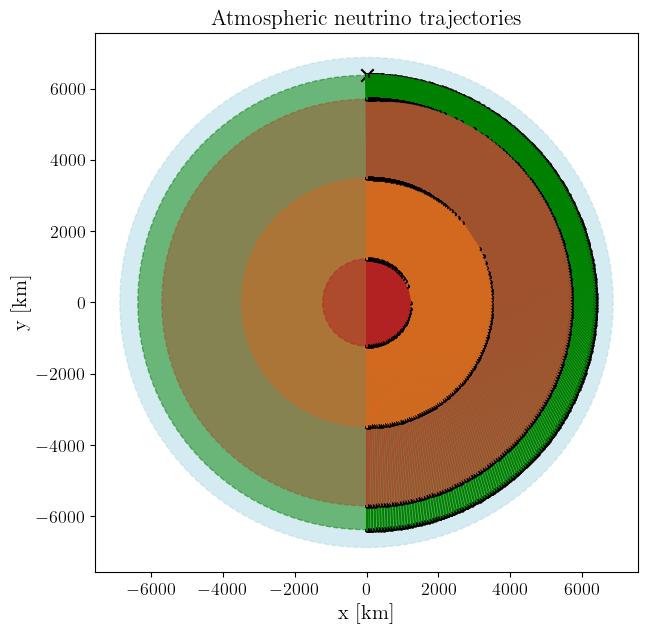

In [3]:
# Check slabs and trajectories
earth.plot_slabs(Thetaz)

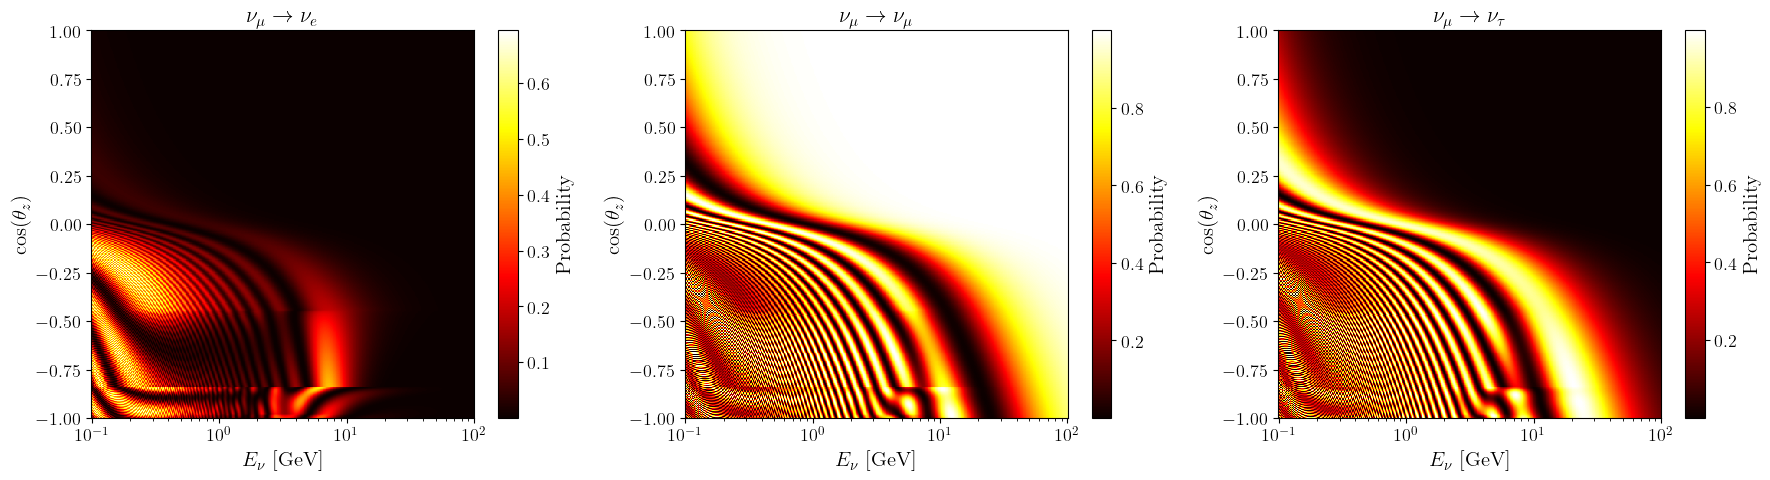

In [4]:
# Plot oscillograms
plot_oscillograms(Thetaz, E, P_mu, "mu", ["e", "mu", "tau"])

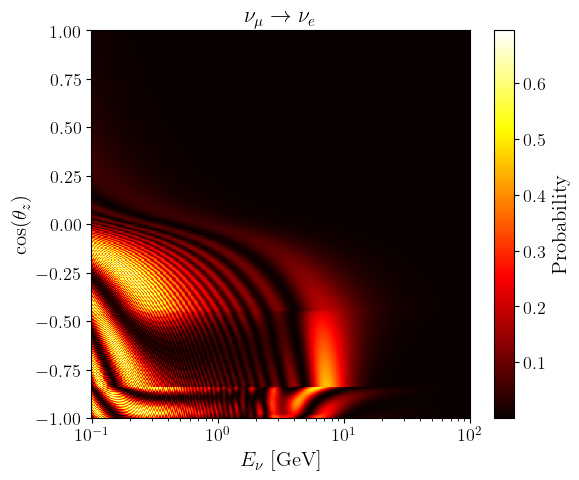

In [5]:
plot_oscillograms(Thetaz, E, P_mu, "mu", ["e"])

In [23]:
# 16:9 aspect ratio
plot_oscillograms(Thetaz, E, P_mu, "mu", ["e"])



# Impact of oscillation parameters

In [6]:
Thetaz = np.linspace(0, np.pi, 500)
E = np.logspace(-1, 2, 500) * u.GeV

## Full treatment

In [7]:
# Full oscillation probabilities

osc_params = OscillationParameters()
earth = EarthModel()

P_mu = compute_oscillograms("mu", Thetaz, E, earth, osc_params)
P_e = compute_oscillograms("e", Thetaz, E, earth, osc_params)


Precomputing slabs for all thetas...
Computing oscillation probabilities...


100%|██████████| 500/500 [00:01<00:00, 278.17it/s]


Done.
Precomputing slabs for all thetas...
Computing oscillation probabilities...


100%|██████████| 500/500 [00:02<00:00, 228.29it/s]

Done.


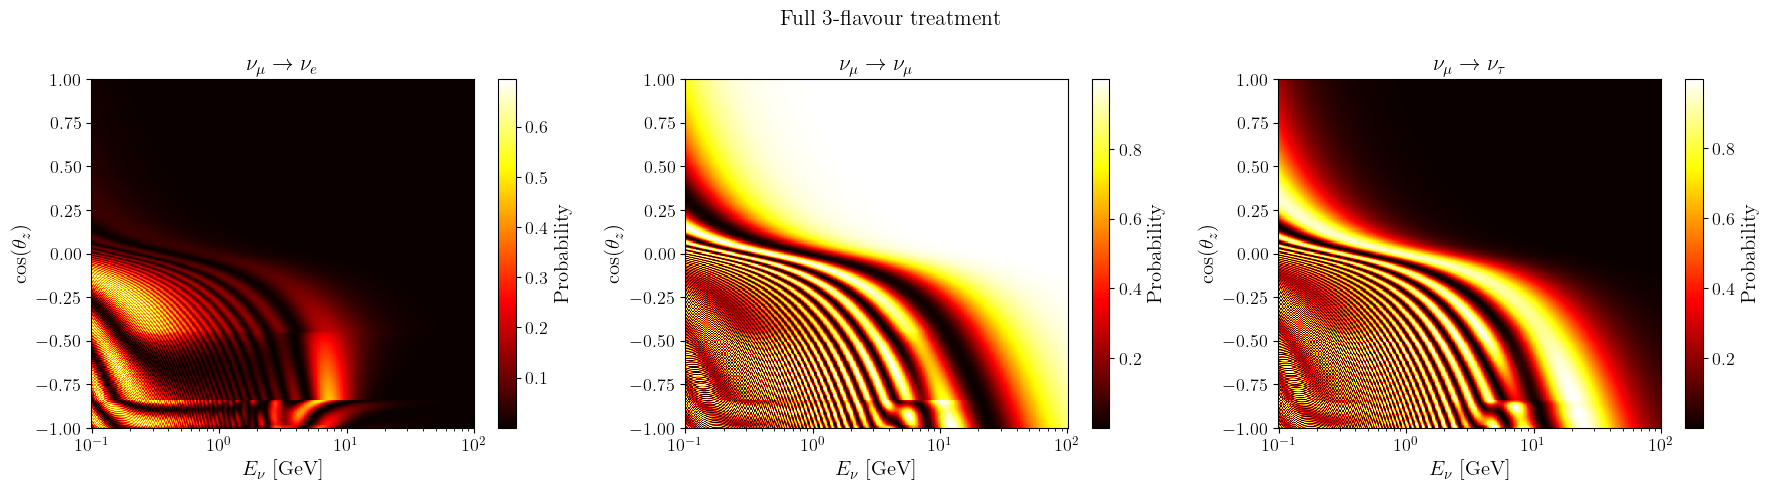

In [8]:
plot_oscillograms(Thetaz, E, P_mu, "mu", ["e", "mu", "tau"], title="Full 3-flavour treatment")

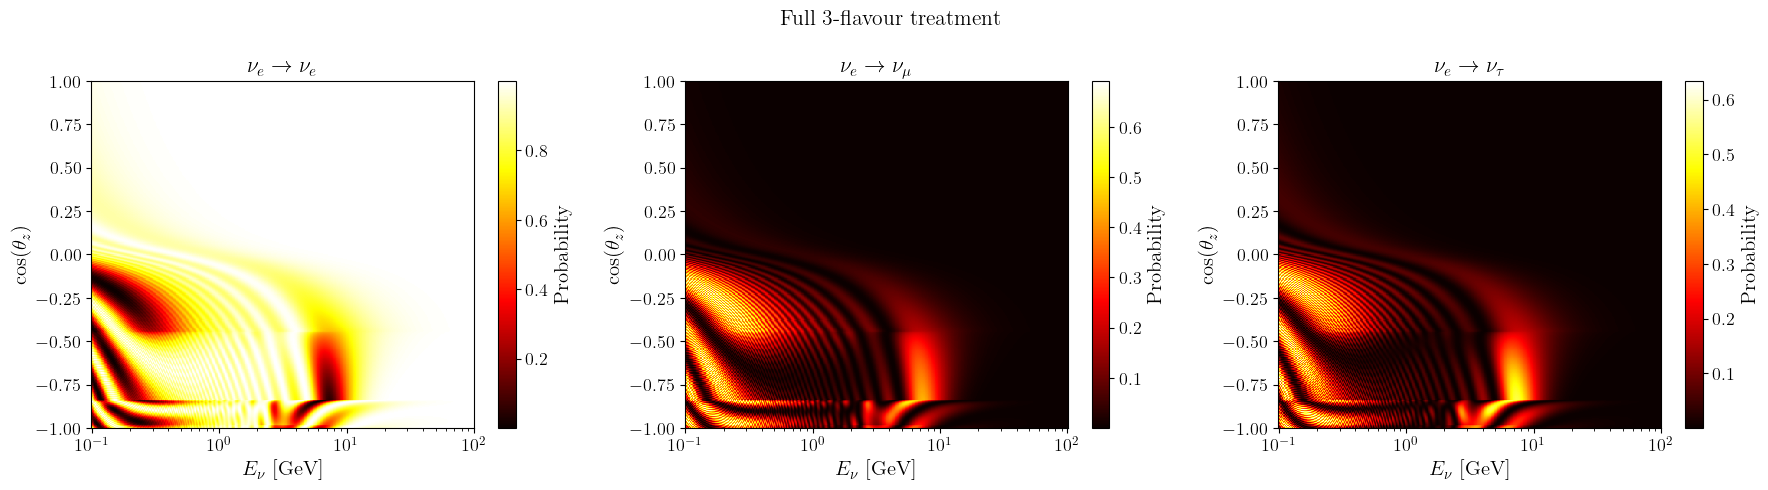

In [9]:
plot_oscillograms(Thetaz, E, P_e, "e", ["e", "mu", "tau"], title="Full 3-flavour treatment")

## $\Delta m_{21}^2 = 0$

In [10]:
# Full oscillation probabilities

osc_params = OscillationParameters(dm21=0*u.eV**2)

earth = EarthModel()

P_mu = compute_oscillograms("mu", Thetaz, E, earth, osc_params)


Precomputing slabs for all thetas...
Computing oscillation probabilities...


100%|██████████| 500/500 [00:02<00:00, 234.72it/s]

Done.


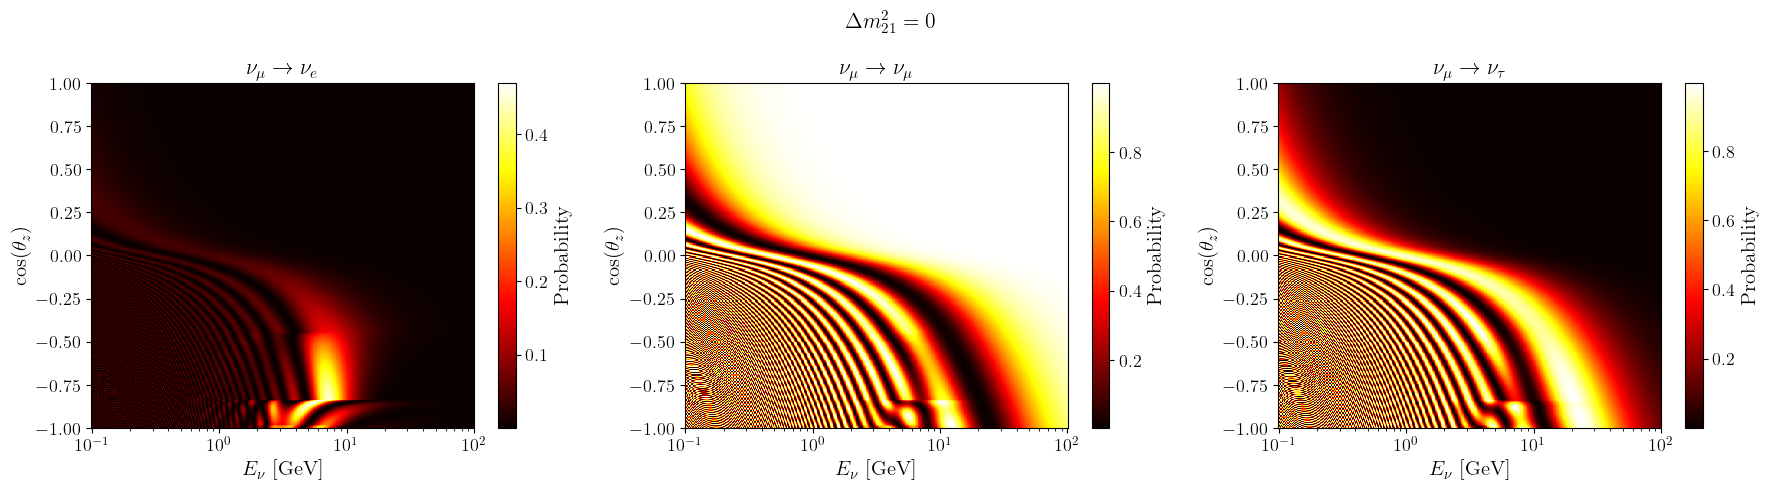

In [11]:
plot_oscillograms(Thetaz, E, P_mu, "mu", ["e", "mu", "tau"], title=r"$\Delta m_{21}^2 = 0$")

## $\Delta m_{32}^2 = 0$

In [12]:
# Full oscillation probabilities

osc_params = OscillationParameters(dm32=0*u.eV**2)

earth = EarthModel()

P_mu = compute_oscillograms("mu", Thetaz, E, earth, osc_params)


Precomputing slabs for all thetas...
Computing oscillation probabilities...


100%|██████████| 500/500 [00:01<00:00, 319.72it/s]

Done.


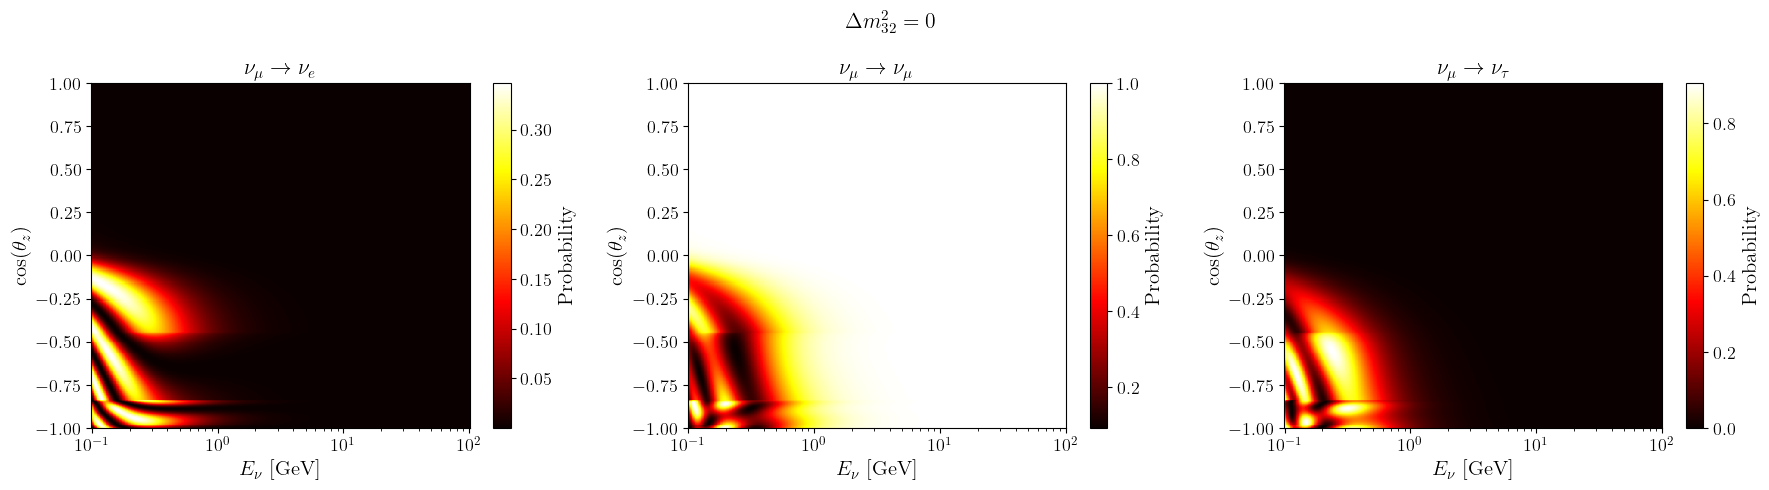

In [13]:
plot_oscillograms(Thetaz, E, P_mu, "mu", ["e", "mu", "tau"], title=r"$\Delta m_{32}^2 = 0$")

## $\delta_\mathrm{CP} = 0$

In [14]:
# Full oscillation probabilities

osc_params = OscillationParameters()

earth = EarthModel()

P_mu_CP = compute_oscillograms("mu", Thetaz, E, earth, osc_params)

osc_params.deltaCP = 0
P_mu_noCP = compute_oscillograms("mu", Thetaz, E, earth, osc_params)


Precomputing slabs for all thetas...
Computing oscillation probabilities...


100%|██████████| 500/500 [00:01<00:00, 312.68it/s]


Done.
Precomputing slabs for all thetas...
Computing oscillation probabilities...


100%|██████████| 500/500 [00:02<00:00, 235.75it/s]

Done.


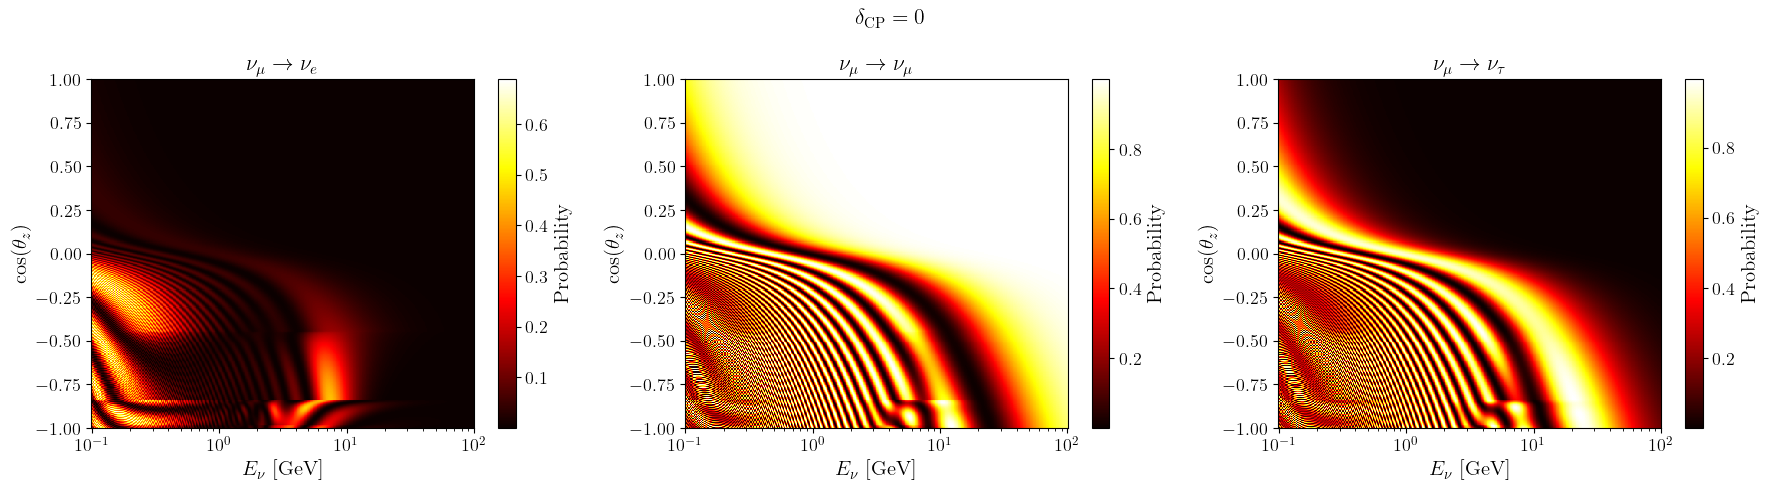

In [15]:
plot_oscillograms(Thetaz, E, P_mu_noCP, "mu", ["e", "mu", "tau"], title=r"$\delta_\mathrm{CP} = 0$")

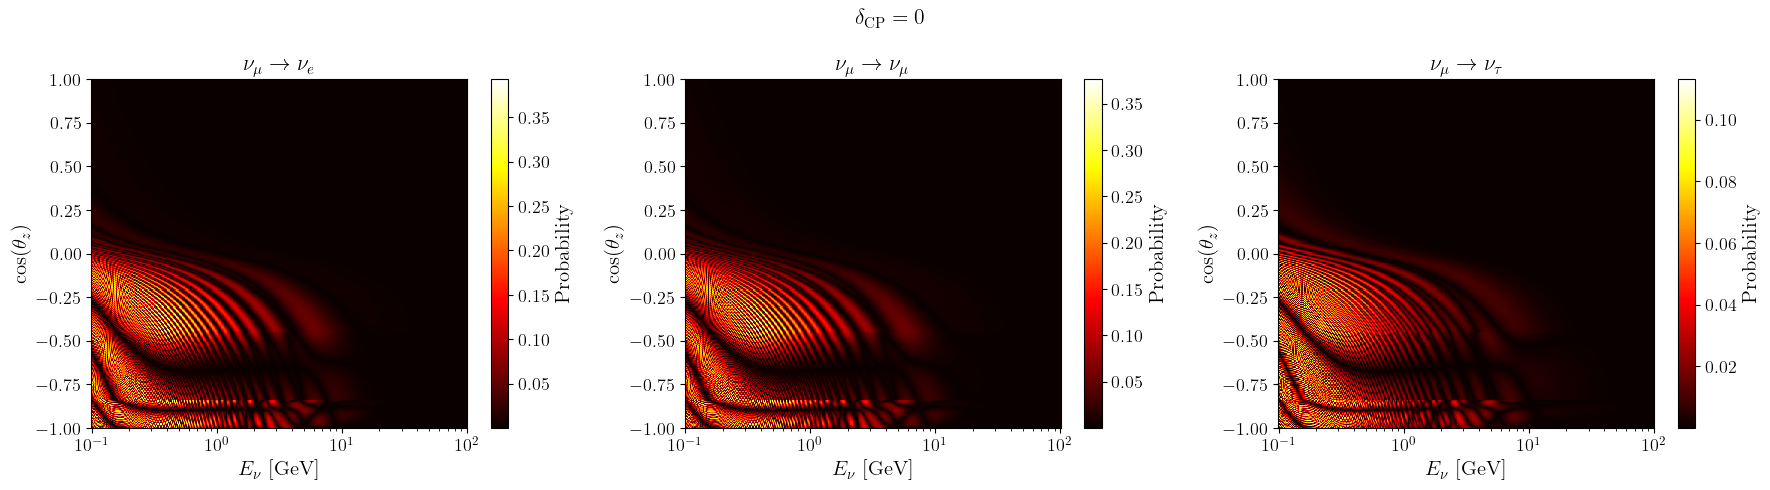

In [16]:
diff = {key: np.abs(P_mu_CP[key] - P_mu_noCP[key]) for key in P_mu_CP.keys()}
plot_oscillograms(Thetaz, E, diff, "mu", ["e", "mu", "tau"], title=r"$\delta_\mathrm{CP} = 0$")

## Vacuum

In [17]:
# Full oscillation probabilities

osc_params = OscillationParameters()

vacuum_layer = Layer("Vacuum", 0, 1e6*u.km, 0*u.g/u.cm**3, 0)

earth = EarthModel(layers=[vacuum_layer])

P_mu = compute_oscillograms("mu", Thetaz, E, earth, osc_params)

P_mu_nubar = compute_oscillograms("mu", Thetaz, E, earth, osc_params, anti=True)


Precomputing slabs for all thetas...
Computing oscillation probabilities...


100%|██████████| 500/500 [00:01<00:00, 452.49it/s]


Done.
Precomputing slabs for all thetas...
Computing oscillation probabilities...


100%|██████████| 500/500 [00:00<00:00, 770.47it/s]

Done.


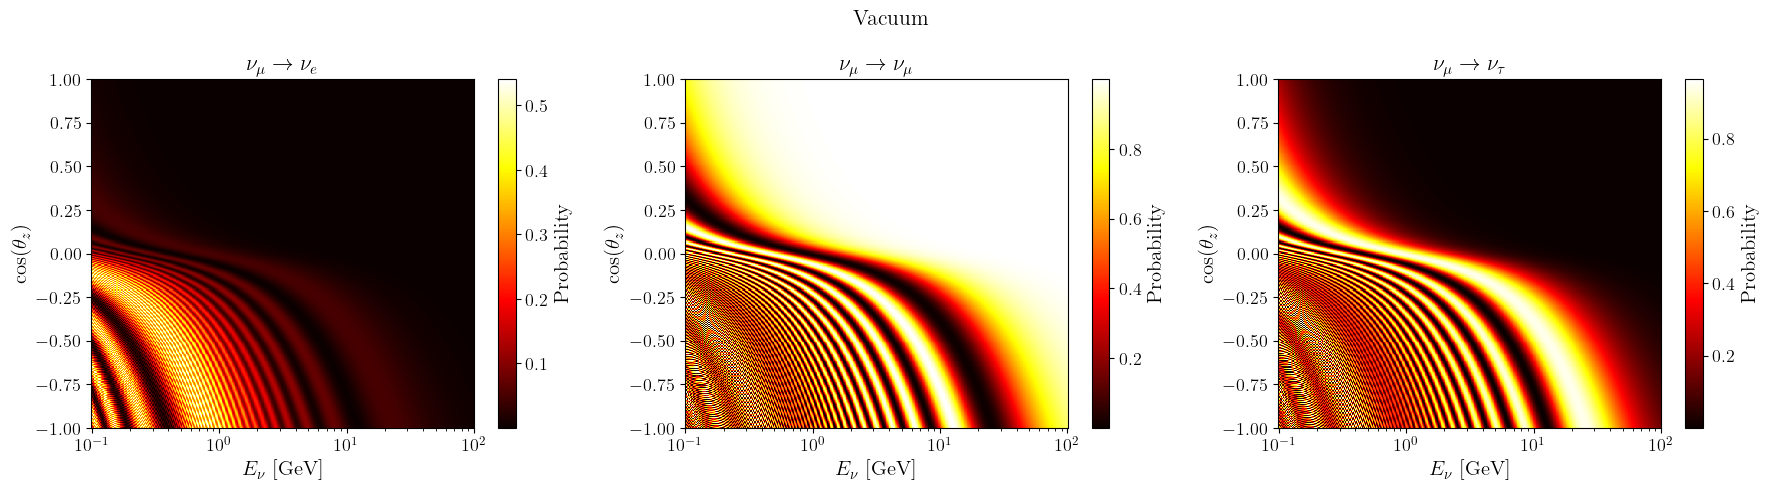

In [18]:
plot_oscillograms(Thetaz, E, P_mu, "mu", ["e", "mu", "tau"], title="Vacuum")

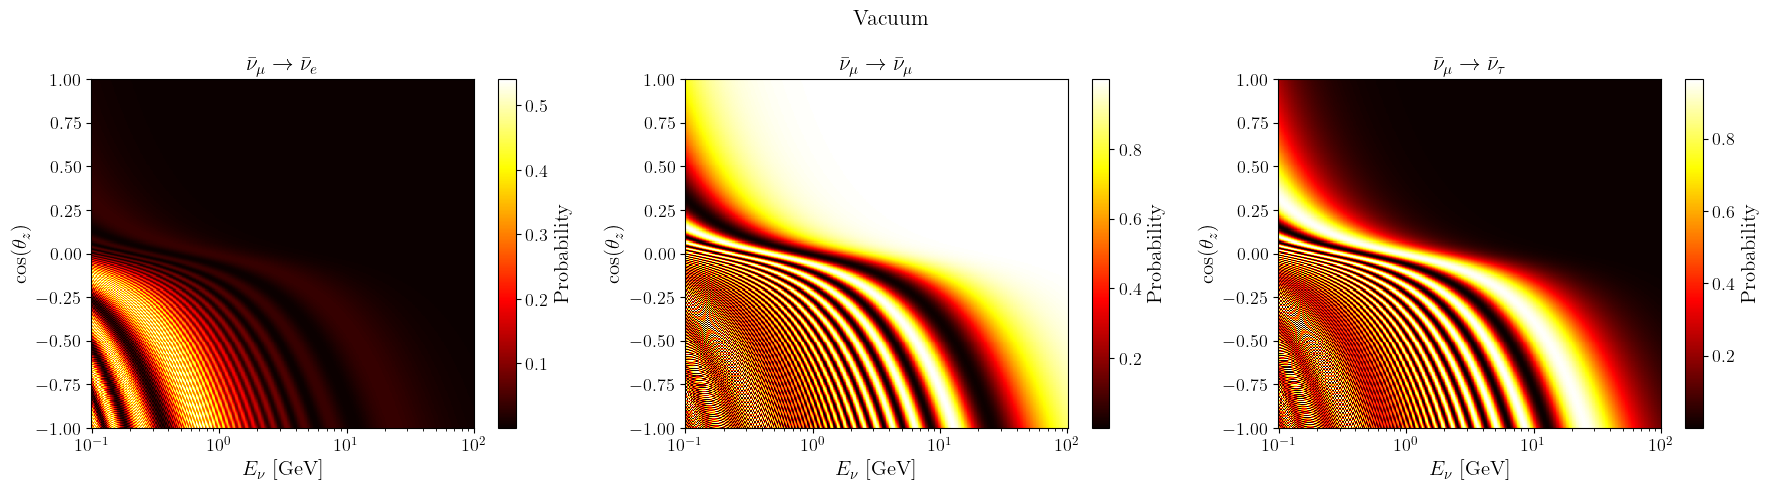

In [19]:
plot_oscillograms(Thetaz, E, P_mu_nubar, "mu", ["e", "mu", "tau"], title="Vacuum", anti=True)

# $\theta_z$ to L

In [ ]:
Thetaz = np.linspace(0, np.pi, 500)
vacuum_layer = Layer("Vacuum", 0, (6371+500)*u.km, 0*u.g/u.cm**3, 0)
earth = EarthModel(layers=[vacuum_layer])
slabs = [earth.compute_slabs(thetaz) for thetaz in Thetaz]
L = np.array([slab[0].thickness.value for slab in slabs])

Precomputing slabs for all thetas...
Computing oscillation probabilities...


100%|██████████| 500/500 [00:00<00:00, 2146.52it/s]


Done.
Precomputing slabs for all thetas...
Computing oscillation probabilities...


100%|██████████| 500/500 [00:00<00:00, 2082.64it/s]


Done.
Precomputing slabs for all thetas...
Computing oscillation probabilities...


100%|██████████| 500/500 [00:00<00:00, 2242.98it/s]


Done.


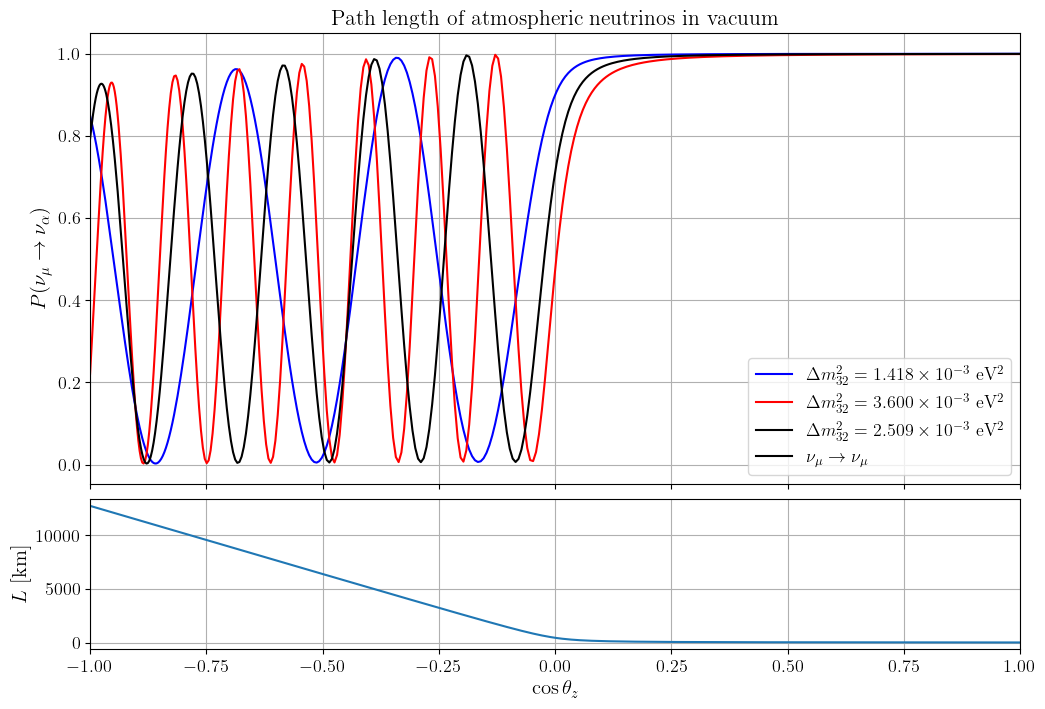

In [80]:
dm232_values=np.array([1.418e-03, 1.527e-03, 1.636e-03, 1.745e-03, 1.854e-03, 1.963e-03, 2.073e-03, 2.182e-03, 2.291e-03, 2.400e-03, 2.618e-03, 2.727e-03, 2.836e-03, 2.945e-03, 3.054e-03, 3.164e-03, 3.273e-03, 3.382e-03, 3.491e-03, 3.600e-03])*1e3
E = np.array([2.5]) * u.GeV

asimov_value = 2.509

# cmap_name = "RdBu_r"
# delta = max(
#             abs(dm232_values.min() - asimov_value),
#             abs(dm232_values.max() - asimov_value)
#         )
# norm = TwoSlopeNorm(
#             vmin=asimov_value - delta,
#             vcenter=asimov_value,
#             vmax=asimov_value + delta
#         )

# cmap = plt.get_cmap(cmap_name)


fig, ax = plt.subplots(2, 1, sharex=True, gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}, figsize=(12, 8))

for dm2, color in zip([dm232_values[0], dm232_values[-1], asimov_value], ["blue", "red", "black"]):

    osc_params = OscillationParameters(dm32=dm2*1e-3*u.eV**2)
    Pmu = compute_oscillograms("mu", Thetaz, E, earth, osc_params)
    #Pe = compute_oscillograms("e", Thetaz, E, earth, osc_params)

    #ax[0].plot(np.cos(Thetaz), 1 - np.sin(1.27 * dm2*1e-3 * L / E.value)**2, color=color, label=rf"$\Delta m^2_{{32}} = {dm2:.3f} \times 10^{{-3}}$ eV$^2$")
    ax[0].plot(np.cos(Thetaz), Pmu["mu"], color=color)
    #ax[0].plot(np.cos(Thetaz), Pmu["tau"], color=color, linestyle="dashed")
    ax[0].plot([], [], color=color, label=rf"$\Delta m^2_{{32}} = {dm2:.3f} \times 10^{{-3}}$ eV$^2$")

ax[0].plot([], [], color="black", label=r"$\nu_\mu \to \nu_\mu$")
#ax[0].plot([], [], color="black", linestyle="dashed", label=r"$\nu_\mu \to \nu_tau$")
# divider = make_axes_locatable(ax[0])
# cax = divider.append_axes("right", size="3%", pad=0.05)

# sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
# sm.set_array([])
# cbar = plt.colorbar(sm, cax=cax)
# cbar.set_label(r"$\Delta m^2_{{32}}$ [$10^{-3}$ eV$^2$]")



ax[1].plot(np.cos(Thetaz), L,)

ax[0].set_ylabel(r"$P(\nu_\mu \to \nu_\alpha)$")
ax[1].set_xlabel(r"$\cos \theta_z$")
ax[1].set_ylabel(r"$L$ [km]")
ax[0].set_title("Path length of atmospheric neutrinos in vacuum")

ax[0].legend()
ax[0].grid()
ax[1].grid()

ax[1].set_xlim(-1, 1)
plt.show()

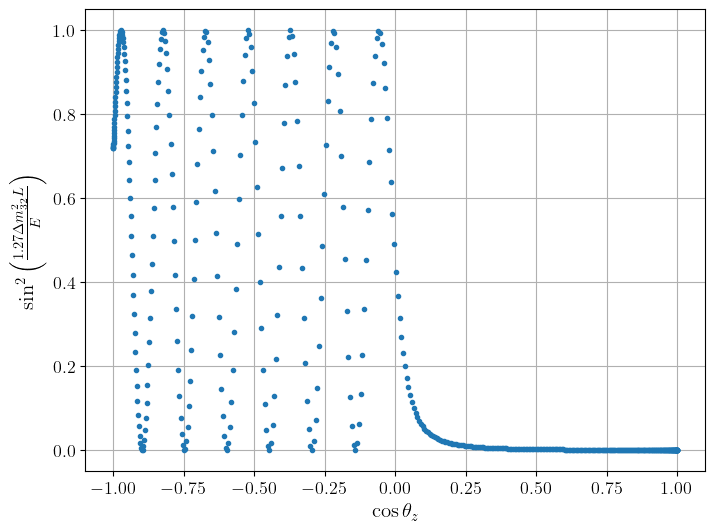

In [ ]:


plt.figure()

plt.plot(np.cos(Thetaz), np.sin(1.27 * dm2.value * L / E.value)**2, ".")

plt.xlabel(r"$\cos \theta_z$")
plt.ylabel(r"$\sin^2\left(\frac{1.27 \Delta m^2_{32} L}{E}\right)$" )

plt.grid()
plt.show()